# Step 1 : Environment Setup and Library Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
dataset_base_path = "./drive/MyDrive/Brain_Tumor_Classification/dataset_extracted/Brain-Tumor-Classification-DataSet-master"
train_dir = os.path.join(dataset_base_path, 'Training')
val_dir = os.path.join(dataset_base_path, 'Testing')

print("Environment is ready. Paths established.")

Mounted at /content/drive
✅ Environment is ready. Paths established.


# Step 2 : Data Augmentation and Optimized DataLoader Setup

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = ImageFolder(root=val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Datasets loaded successfully. Classes: {train_dataset.classes}")

✅ Datasets loaded successfully. Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


# Step 3 : Model Re-initialization (ResNet18 Backbone)

In [ ]:
# We start with ImageNet weights to completely eliminate Day 5's overfitted bias
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Unfreeze ALL layers for a comprehensive deep fine-tuning phase
for param in model.parameters():
    param.requires_grad = True

print(f"Network successfully initialized on {device.type.upper()}. All parameters unfrozen.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


🔓 Network successfully initialized on CUDA. All parameters unfrozen.


# Step 4 : Loss Function with Class Weights & Anti-Overfitting Optimizer

In [ ]:
# Heavily weight Class 0 (Glioma) to address its low recall in previous steps
weights = torch.tensor([2.5, 1.0, 1.0, 1.0], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Balanced learning rate (1e-4) paired with stricter weight decay (2e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0002)

print("Optimizer and Loss criterion configured with balanced constraints.")

🎯 Optimizer and Loss criterion configured with balanced constraints.


# Step 5 : Smart Training Loop with Validation-Driven Checkpointing

In [ ]:
epochs = 15
best_val_acc = 0.0  # CRITICAL: We now track the highest validation accuracy, NOT train accuracy
checkpoint_dir = "./drive/MyDrive/Brain_Tumor_Classification"
checkpoint_path_v3 = os.path.join(checkpoint_dir, 'best_brain_tumor_model_v3.pth')

scaler = torch.amp.GradScaler('cuda')
print(" Launching Version 3 Training Strategy...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = (correct_train / total_train) * 100

    # --- VALIDATION / TESTING PHASE ---
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = (val_correct / val_total) * 100

    # Monitor both to catch the exact moment overfitting begins
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || Val Acc: {val_acc:.2f}%")

    # Save checkpoint ONLY if validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': val_acc
        }, checkpoint_path_v3)
        print(f"--> 🔥 New Best Model Captured with Val Acc: {val_acc:.2f}%")

    torch.cuda.empty_cache()

print(f"\n Process Complete. Best Verifiable Validation Accuracy: {best_val_acc:.2f}%")

🚀 Launching Version 3 Training Strategy...
Epoch [1/15] | Train Loss: 0.4133 | Train Acc: 82.02% || Val Acc: 72.84%
--> 🔥 New Best Model Captured with Val Acc: 72.84%
Epoch [2/15] | Train Loss: 0.2216 | Train Acc: 91.36% || Val Acc: 75.89%
--> 🔥 New Best Model Captured with Val Acc: 75.89%
Epoch [3/15] | Train Loss: 0.1378 | Train Acc: 94.36% || Val Acc: 75.13%
Epoch [4/15] | Train Loss: 0.1084 | Train Acc: 95.89% || Val Acc: 79.70%
--> 🔥 New Best Model Captured with Val Acc: 79.70%
Epoch [5/15] | Train Loss: 0.1053 | Train Acc: 96.17% || Val Acc: 76.65%
Epoch [6/15] | Train Loss: 0.0626 | Train Acc: 97.70% || Val Acc: 77.16%
Epoch [7/15] | Train Loss: 0.0742 | Train Acc: 97.53% || Val Acc: 78.93%
Epoch [8/15] | Train Loss: 0.0476 | Train Acc: 98.26% || Val Acc: 80.96%
--> 🔥 New Best Model Captured with Val Acc: 80.96%
Epoch [9/15] | Train Loss: 0.0582 | Train Acc: 97.98% || Val Acc: 75.38%
Epoch [10/15] | Train Loss: 0.0855 | Train Acc: 97.04% || Val Acc: 78.43%
Epoch [11/15] | Train 

# Step 6 : Final Evaluation and Confusion Matrix Visualization

Successfully loaded best V3 model weights (Val Acc: 83.50%)


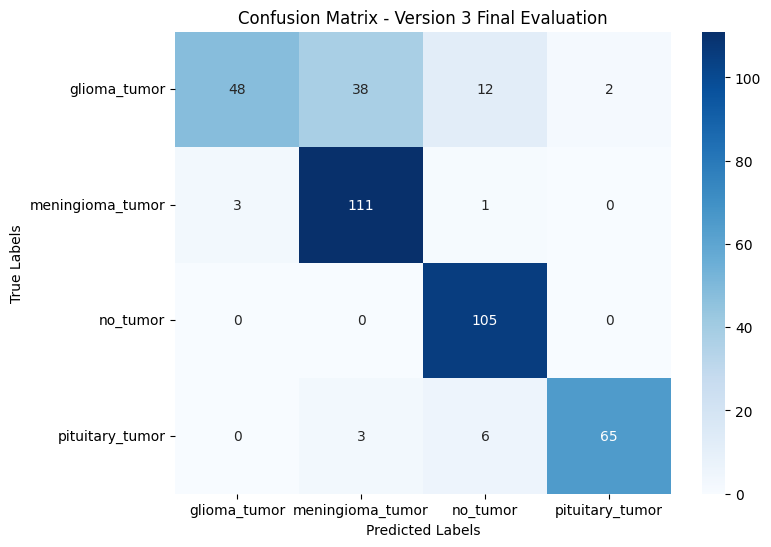

                  precision    recall  f1-score   support

    glioma_tumor       0.94      0.48      0.64       100
meningioma_tumor       0.73      0.97      0.83       115
        no_tumor       0.85      1.00      0.92       105
 pituitary_tumor       0.97      0.88      0.92        74

        accuracy                           0.84       394
       macro avg       0.87      0.83      0.83       394
    weighted avg       0.86      0.84      0.82       394



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load the absolute best version saved during training
if os.path.exists(checkpoint_path_v3):
    checkpoint = torch.load(checkpoint_path_v3, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Successfully loaded best V3 model weights (Val Acc: {checkpoint['accuracy']:.2f}%)")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate Confusion Matrix Diagram
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_dataset.classes, yticklabels=val_dataset.classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Version 3 Final Evaluation')
plt.show()

print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))